In [10]:
import numpy as np
import pandas as pd

In [11]:
df = pd.read_csv('course_lead_scoring.csv')
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [12]:
df.dtypes

lead_source                     str
industry                        str
number_of_courses_viewed      int64
annual_income               float64
employment_status               str
location                        str
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [13]:
categorical = ['lead_source','industry','employment_status','location']
numerical = ['number_of_courses_viewed','annual_income','interaction_count','lead_score']
for cat in categorical:
    df[cat] = df[cat].fillna('NA')
for num in numerical:
    df[num] = pd.to_numeric(df[num]).fillna(0.0)
df.isnull().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [14]:
df['converted'].head()

0    1
1    0
2    1
3    0
4    1
Name: converted, dtype: int64

In [15]:
from sklearn.model_selection import train_test_split
df_full_train, df_test = train_test_split(df,test_size=0.2,random_state=1)
df_train, df_val = train_test_split(df_full_train,test_size=0.25,random_state=1)

In [16]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression 
def train_model(df,y_train,C=0.1):
    dicts = df[categorical+numerical].to_dict(orient='records')
    dv = DictVectorizer()
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear',C=C, max_iter=1000)
    model.fit(X_train,y_train)
    return dv, model

def predict(df, dv, model):
    dicts = df[categorical+numerical].to_dict(orient='records')
    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:,1]
    return y_pred

In [17]:
y_full_train = df_full_train.converted
y_train = df_train.converted
y_val = df_val.converted
y_test = df_test.converted

df_full_train = df_full_train.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

del df_full_train['converted']
del df_train['converted']
del df_val['converted']
del df_test['converted']

In [18]:
from sklearn.metrics import roc_auc_score
scores=[]
for num in numerical:
    s = df_train[num].values
    auc = roc_auc_score(y_train,s)
    if auc<0.5:
        s = -s
        auc = roc_auc_score(y_train,s)
    scores.append(auc)
print(numerical)
print(scores)        

['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']
[0.7635680590007088, 0.5519578313253012, 0.738270176293409, 0.6144993577250176]


# Question 1 Answer: number_of_courses_viewed has the highest score

In [19]:
from sklearn.metrics import roc_auc_score

dv, model = train_model(df_train, y_train, C=1.0)
y_pred = predict(df_val, dv, model)
score = roc_auc_score(y_val, y_pred)
print(round(score,3))

0.817


# Question 2 Answer: AUC = 0.817

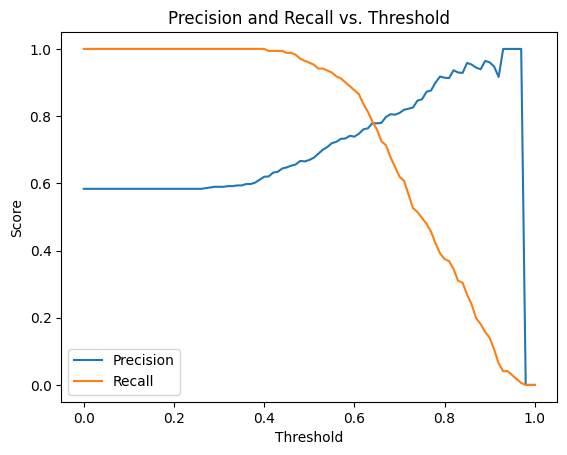

Threshold de intersección (aprox): 0.98
[0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7370689655172414, 0.7386609071274298, 0.7402597402597402, 0.7418655097613882, 0.7418655097613882, 0.7418655097613882, 0.7434782608695651, 0.7434782608695651, 0.7450980392156863, 0.7450980392156863, 0.7483588621444202, 0.7483588621444202, 0.7516483516483516, 0.7583148558758315, 0.7651006711409396, 0.7640449438202247, 0.7727272727272728, 0.774487471526196, 0.7816091954022989, 0.7824074074074073, 0.7860465116279071, 0.7868852459016393, 

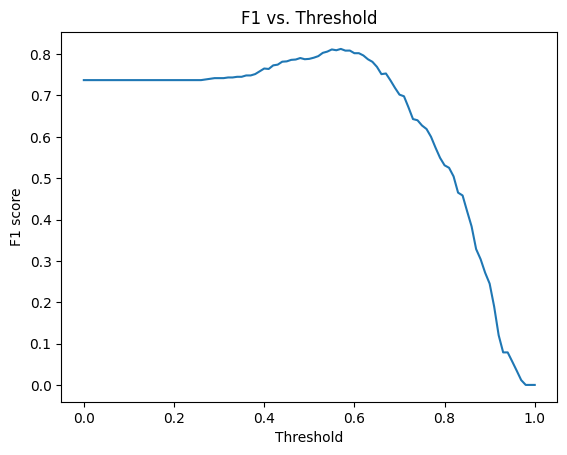

In [27]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from matplotlib import pyplot as plt
thresholds = np.arange(0.0, 1.001, 0.01)
precisions = []
recalls = []
f1_score=[]
for t in thresholds:
    val_pred = (y_pred >= t).astype(int)
   
    p = precision_score(y_val, val_pred, zero_division=0)
    r = recall_score(y_val, val_pred, zero_division=0)
    precisions.append(p)
    recalls.append(r)
    if(p+r==0):
        f1_score.append(0.0)
    else:
        f1_score.append(2*p*r/(p+r))

# Plot
plt.figure()
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs. Threshold')
plt.legend()
plt.show()

# Encontrar "intersección" aproximada: el threshold donde |P - R| es mínimo
diff = np.abs(np.array(precisions) - np.array(recalls))
t_intersect = thresholds[np.argmin(diff)]
print("Threshold de intersección (aprox):", round(float(t_intersect), 3))
print(f1_score)
plt.figure()
plt.plot(thresholds, f1_score)
plt.xlabel('Threshold')
plt.ylabel('F1 score')
plt.title('F1 vs. Threshold')
plt.show()

